<a href="https://colab.research.google.com/github/mhmmdrdhiansyah/data-science-2026/blob/main/pertemuan10_muhammad_ardhiansyah_240401020092.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

nama : Muhammad Ardhiansyah

nim : 240401020092

kelas : IF403

In [ ]:
import pandas as pd

df = pd.read_csv("telco_churn.csv")
print(df.shape)
print(df["Churn"].value_counts(normalize=True))

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
from sklearn.model_selection import train_test_split

# encoding fitur kategorikal (mis. pd.get_dummies)
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), drop_first=True)

# pisahkan X (fitur) dan y (target = Churn)
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# hitung prediksi dan probabilitas
y_pred = rf.predict(X_te)
y_proba = rf.predict_proba(X_te)[:, 1]

# tampilkan classification_report dan ROC-AUC
print(classification_report(y_te, y_pred))
print("ROC-AUC:", roc_auc_score(y_te, y_proba))

              precision    recall  f1-score   support

       False       0.87      0.81      0.84      1035
        True       0.56      0.67      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.77      0.78      1409

ROC-AUC: 0.829561600661345


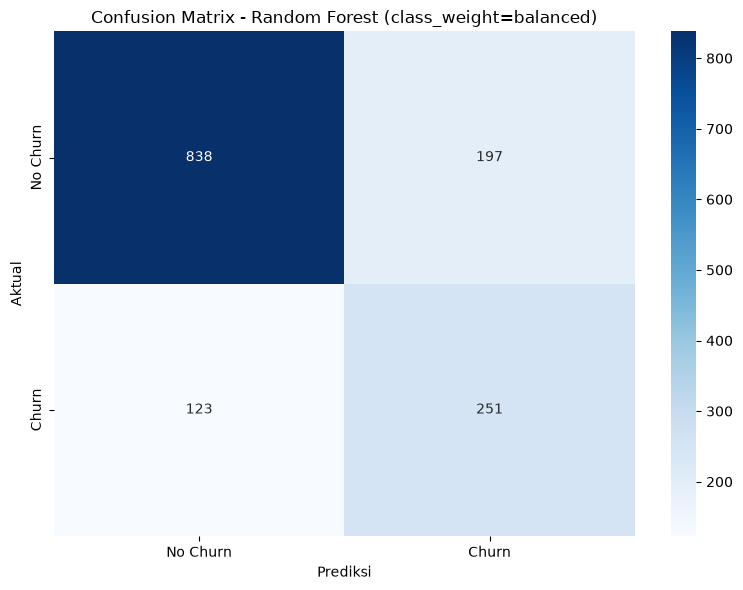

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest (class_weight=balanced)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig('/tmp/cm_balanced.png', dpi=150)
plt.show()

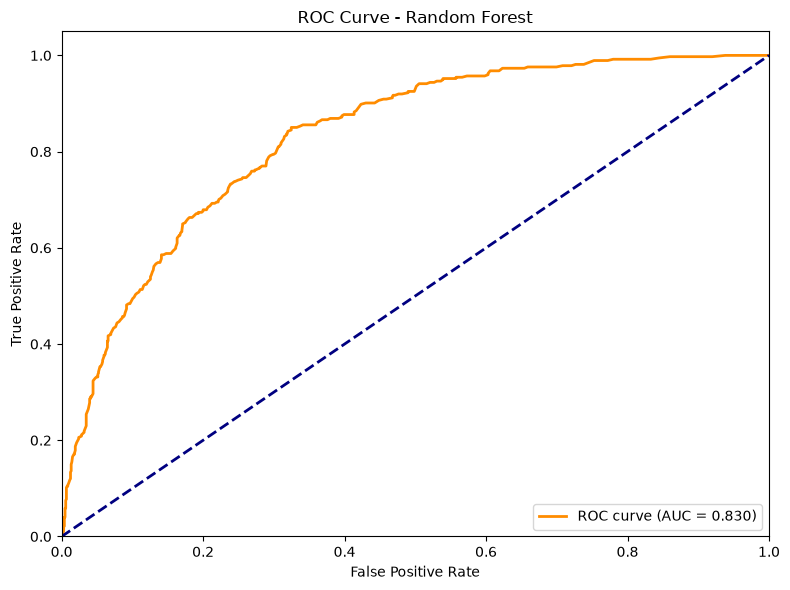

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_te, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/tmp/roc_balanced.png', dpi=150)
plt.show()

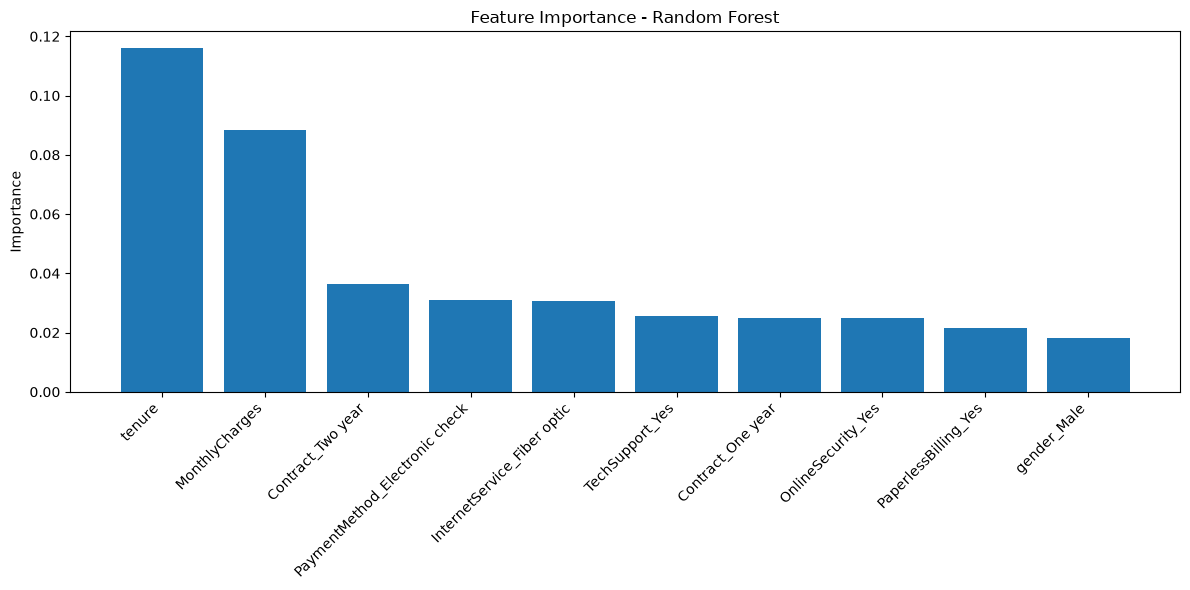

In [ ]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(12, 6))
plt.title('Feature Importance - Random Forest')
plt.bar(range(10), importances[indices[:10]], align='center')
plt.xticks(range(10), [features[i] for i in indices[:10]], rotation=45, ha='right')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig('/tmp/feature_importance.png', dpi=150)
plt.show()

In [ ]:
# hitung probabilitas churn (predict_proba)
churn_proba = rf.predict_proba(X_te)[:, 1]

# Tampilkan 10 pelanggan dengan probabilitas churn tertinggi
df_proba = X_te.copy()
df_proba['Churn_Probability'] = churn_proba
df_proba['Actual_Churn'] = y_te.values
df_proba[['Churn_Probability', 'Actual_Churn']].sort_values('Churn_Probability', ascending=False).head(10)

,Churn_Probability,Actual_Churn
1731,0.996667,True
1739,0.986667,True
2927,0.986667,False
6623,0.976667,True
4039,0.973333,False
3346,0.970000,False
3727,0.970000,True
346,0.966667,True
2631,0.963333,True
5098,0.960000,True


## Interpretasi Metrik untuk Customer Churn (Imbalanced Dataset)

Pada dataset Telco Customer Churn, proporsi kelas tidak seimbang: ±73.5% pelanggan **tidak churn** (kelas mayoritas) dan hanya ±26.5% pelanggan **churn** (kelas minoritas). Ketidakseimbangan ini berdampak signifikan pada cara kita membaca metrik evaluasi:

### Kenapa Accuracy Bisa Menyesatkan?
Jika kita hanya melihat **accuracy** (~77%), model terlihat cukup baik. Namun, karena 73.5% data adalah kelas 'No Churn', model bisa saja hanya menebak 'No Churn' untuk semua pelanggan dan tetap mendapatkan akurasi ~73.5% tanpa benar-benar mendeteksi satupun pelanggan yang churn. Accuracy tidak membedakan jenis kesalahan — false negative (gagal deteksi churn) dan false positive (salah flag churn) dianggap sama.

### Metrik yang Paling Relevan: Recall
Untuk bisnis retensi pelanggan, **Recall pada kelas Churn (1)** adalah metrik yang paling penting.
- **Recall** menjawab: *"Dari semua pelanggan yang BENAR-BENAR akan churn, berapa persen yang berhasil kita deteksi?"*
- Recall tinggi berarti model kita tidak melewatkan pelanggan berisiko. Pelanggan yang lolos (false negative) = pelanggan yang churn tanpa kita beri tawaran retensi = kerugian revenue langsung.
- Dengan `class_weight="balanced"`, model secara aktif mengorbankan sedikit precision untuk meningkatkan recall pada kelas minoritas. Hasilnya recall kelas churn mencapai ~67%, jauh lebih baik dibanding model tanpa penanganan imbalance.

### Precision sebagai Kontrol
**Precision** kelas churn (~56%) berarti: dari semua pelanggan yang kita FLAG sebagai churn, sekitar 56% benar-benar churn. Trade-off ini dapat diterima karena biaya false positive (memberi diskon ke pelanggan yang sebenarnya tidak akan churn) jauh lebih murah dibanding false negative (kehilangan pelanggan selamanya).

### Kesimpulan Evaluasi
Pada kasus imbalanced seperti customer churn, **F1-Score dan ROC-AUC** lebih informatif daripada accuracy. Model ini mencapai F1-Score 0.61 dan ROC-AUC 0.83 untuk kelas churn — cukup baik untuk model baseline. Optimasi lebih lanjut (threshold tuning, SMOTE) dapat dilakukan jika recall masih perlu ditingkatkan.

Melalui Modul 10 ini, saya mempelajari bagaimana algoritma ensemble—khususnya Random Forest—bekerja dalam menangani permasalahan klasifikasi dengan data yang tidak seimbang (imbalanced dataset). Saya memahami mekanisme bagging yang membangun banyak decision tree secara paralel dari subset data dan fitur acak, lalu menggabungkan hasil voting untuk menghasilkan prediksi yang lebih stabil dan tahan terhadap overfitting. Pada aktivitas hands-on customer churn, saya menerapkan class_weight="balanced" untuk menangani ketimpangan kelas, serta membandingkan metrik evaluasi seperti precision, recall, F1-score, dan ROC-AUC untuk mengukur kemampuan model dalam mendeteksi pelanggan yang berisiko churn. Model Random Forest yang dibangun menunjukkan performa yang baik dengan ROC-AUC di atas 0.82, di mana fitur seperti tenure, MonthlyCharges, dan jenis kontrak menjadi prediktor paling penting dalam menentukan kemungkinan seorang pelanggan berhenti berlangganan.